In [5]:
import numpy as np
import string
from spectral_cube import SpectralCube
import matplotlib.pyplot as plt
from astropy.wcs import WCS
import astropy.units as u
from astropy.io import fits
from astropy.wcs.utils import skycoord_to_pixel
from astropy.wcs.utils import pixel_to_skycoord
from astropy.coordinates import SkyCoord
from matplotlib.patches import Ellipse
from astropy.stats import mad_std
import matplotlib as mpl
from astropy import units as u
from radio_beam import Beam
from astropy.wcs.utils import proj_plane_pixel_area


In [6]:
hdul = fits.open('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/Continuum/HOPS-164_Continuum_natural_thres0.4mJy.pbcor.fits')

Beam: BMAJ=1.20131540298468 arcsec BMIN=0.9665114879606401 arcsec BPA=85.17520141602 deg
19.454966477132842 K
beam.sr: 3.0922757874253435e-11 sr
Jy/beam


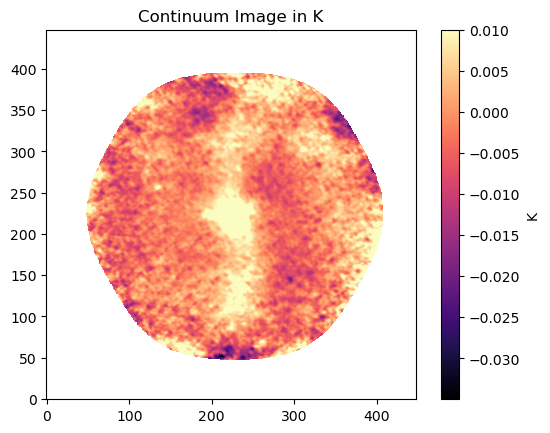

Sigma (RMS noise): 0.0024422219 K


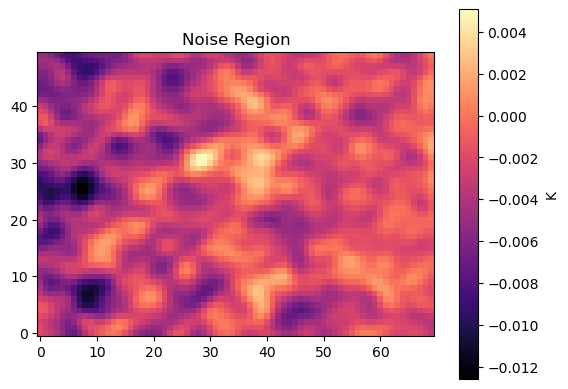

In [10]:

data = hdul[0].data.squeeze()
header = hdul[0].header

# Beam info
beam = Beam.from_fits_header(header)
print(beam)
print((1 * u.Jy).to(u.K, equivalencies=u.brightness_temperature(frequency=232.6*u.GHz, beam_area=beam.sr)))
print("beam.sr:", beam.sr.to(u.sr))
print(hdul[0].header.get('BUNIT'))

# Frequency
freq = 232.6 * u.GHz

# Convert Jy/beam -> K
jybeam_to_K = u.Jy.to(
    u.K,
    equivalencies=u.brightness_temperature(
        frequency=freq,
        beam_area=beam.sr
    )
)

data_K = data * jybeam_to_K

# Plot
plt.imshow(data_K, origin='lower', vmax=0.01, cmap='magma')
plt.colorbar(label='K')
plt.title("Continuum Image in K")
plt.show()

# Noise region
noise_region = data_K[200:250, 100:170]

sigma = np.nanstd(noise_region)

print("Sigma (RMS noise):", sigma, "K")

# Plot noise region
plt.imshow(noise_region, origin='lower', cmap='magma')
plt.colorbar(label='K')
plt.title("Noise Region")
plt.show()

In [2]:
cube_12CO=SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/CO/HOPS164_CO_Tp12m7m_Combine_pbcor_masked_finding_rms.fits')
cube_12CO.allow_huge_operations = True 
cube_12CO = cube_12CO.to(u.K).with_spectral_unit(u.km/u.s)

Mean Moment 5 (noise): 0.1258010498682635 K


/Users/ivarismartinez/anaconda3/envs/umbrella/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


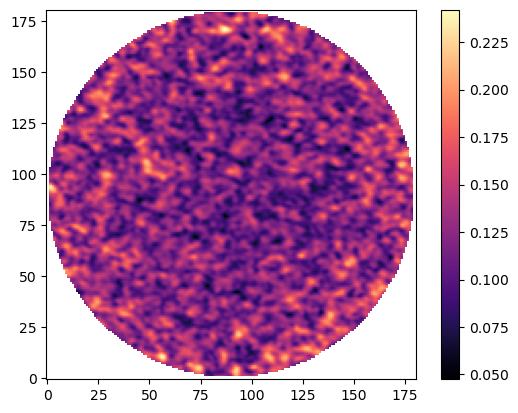

In [3]:
# Emission:
vmin_12CO = -4.6
vmax_12CO = 19.2

# Finding Sigma:
noise_slab_12CO = cube_12CO.spectral_slab(44.9*u.km/u.s, 46.9*u.km/u.s)
moment5_map_12CO = noise_slab_12CO.std(axis=0)

plt.imshow(moment5_map_12CO.data, cmap='magma', origin='lower')
plt.colorbar()

mean_moment5_12CO = np.nanmean(moment5_map_12CO.value)
print("Mean Moment 5 (noise):", mean_moment5_12CO,'K')

In [4]:
cube_13CO = SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/13CO/HOPS164_13CO_Tp12m7m_Combine_pbcor_masked_finding_rms.fits')
cube_13CO = cube_13CO.to(u.K).with_spectral_unit(u.km/u.s)

Mean Moment 5 (noise): 0.16657127071643585 K


/Users/ivarismartinez/anaconda3/envs/umbrella/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


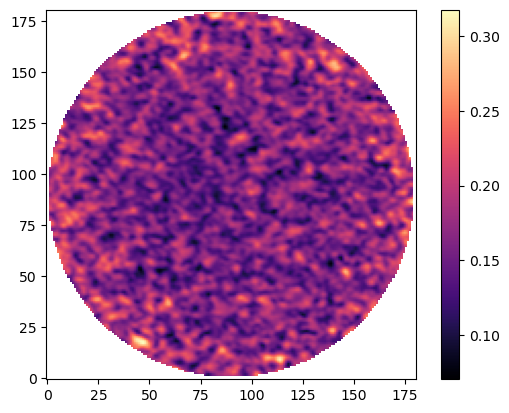

In [5]:
vmin_13CO = 1.4
vmax_13CO = 9.8

# Finding Sigma:
noise_slab_13CO = cube_13CO.spectral_slab(11.7*u.km/u.s, 13.4*u.km/u.s)
moment5_map_13CO = noise_slab_13CO.std(axis=0)

plt.imshow(moment5_map_13CO.data, cmap='magma', origin='lower')
plt.colorbar()

mean_moment5_13CO = np.nanmean(moment5_map_13CO.value)
print("Mean Moment 5 (noise):", mean_moment5_13CO,'K')

In [6]:
cube_C18O = SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/C18O/HOPS164_C18O_Tp12m7m_Combine_pbcor_masked_finding_rms.fits')
cube_C18O = cube_C18O.to(u.K).with_spectral_unit(u.km/u.s)

/Users/ivarismartinez/anaconda3/envs/umbrella/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Mean Moment 5 (noise): 0.12873892466532347 K


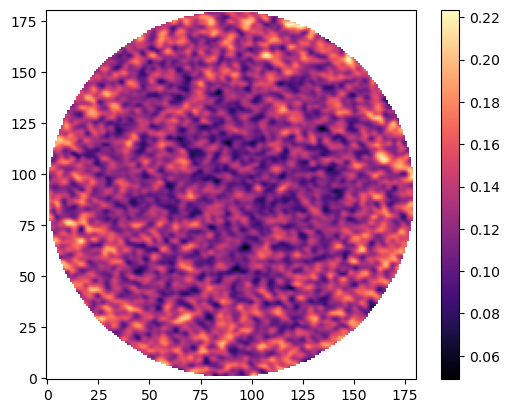

In [7]:
# Encompass all emission:
vmin_C18O = 3.7
vmax_C18O = 8.2

# Finding Sigma:
noise_slab_C18O = cube_C18O.spectral_slab(11.7*u.km/u.s, 13.4*u.km/u.s)
moment5_map_C18O = noise_slab_C18O.std(axis=0)

plt.imshow(moment5_map_C18O.data, cmap='magma', origin='lower')
plt.colorbar()

mean_moment5_C18O = np.nanmean(moment5_map_C18O.value)
print("Mean Moment 5 (noise):", mean_moment5_C18O,'K')

In [8]:
cube_H2CO = SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/H2CO/HOPS164_H2CO_Tp12m7m_Combine_pbcor_masked_finding_rms.fits')
cube_H2CO = cube_H2CO.to(u.K).with_spectral_unit(u.km/u.s)

Mean Moment 5 (noise): 0.11458095024492512 K


/Users/ivarismartinez/anaconda3/envs/umbrella/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


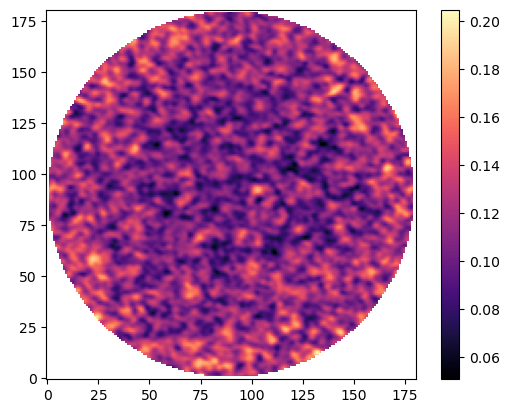

In [9]:
# Emission
vmin_H2CO = 3.0
vmax_H2CO = 10.7

# Finding Sigma:
noise_slab_H2CO = cube_H2CO.spectral_slab(11.7*u.km/u.s, 13.4*u.km/u.s)
moment5_map_H2CO = noise_slab_H2CO.std(axis=0)

plt.imshow(moment5_map_H2CO.data, cmap='magma', origin='lower')
plt.colorbar()

mean_moment5_H2CO = np.nanmean(moment5_map_H2CO.value)
print("Mean Moment 5 (noise):", mean_moment5_H2CO,'K')

In [10]:
# Cut cube
cube_N2Dp = SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_large_sm_reb_finding_rms.fits')
cube_N2Dp = cube_N2Dp.to(u.K).with_spectral_unit(u.km/u.s)

Mean Moment 5 (noise): 0.06122444926050131 K


/Users/ivarismartinez/anaconda3/envs/umbrella/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


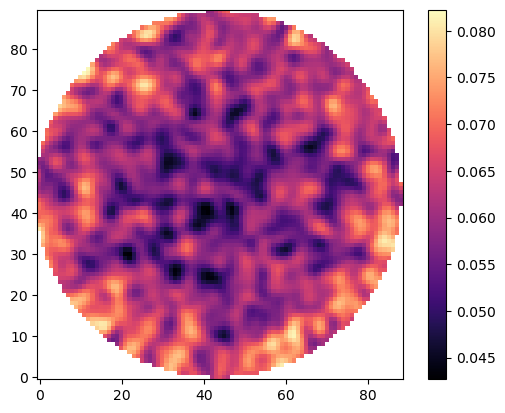

In [11]:
vmin_N2Dp = 3.9
vmax_N2Dp = 7.5

# Finding Sigma:
noise_slab_N2Dp = cube_N2Dp.spectral_slab(10*u.km/u.s, 20*u.km/u.s)
moment5_map_N2Dp = noise_slab_N2Dp.std(axis=0)

plt.imshow(moment5_map_N2Dp.data, cmap='magma', origin='lower')
plt.colorbar()

mean_moment5_N2Dp = np.nanmean(moment5_map_N2Dp.value)
print("Mean Moment 5 (noise):", mean_moment5_N2Dp,'K')

In [12]:
cube_N2Dp = SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_Tp12m7m_large_Combine_pbcor_finding_rms.fits')
cube_N2Dp = cube_N2Dp.to(u.K).with_spectral_unit(u.km/u.s)


/Users/ivarismartinez/anaconda3/envs/umbrella/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Mean Moment 5 (noise): 0.15535306232990254 K


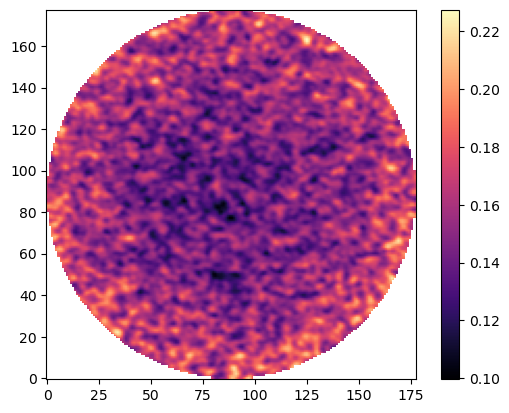

In [13]:
vmin_N2Dp = 3.9
vmax_N2Dp = 7.5

# Finding Sigma:
noise_slab_N2Dp = cube_N2Dp.spectral_slab(10*u.km/u.s, 20*u.km/u.s)
moment5_map_N2Dp = noise_slab_N2Dp.std(axis=0)

plt.imshow(moment5_map_N2Dp.data, cmap='magma', origin='lower')
plt.colorbar()

mean_moment5_N2Dp = np.nanmean(moment5_map_N2Dp.value)
print("Mean Moment 5 (noise):", mean_moment5_N2Dp,'K')

In [ ]:
cube_robust = SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/Continuum/HOPS-164_cont_robust0.5.pbcor.fits')
cube_robust = cube_robust.to(u.K)
image = cube_robust[0]

Sigma (RMS noise): 0.24781940115044984 K


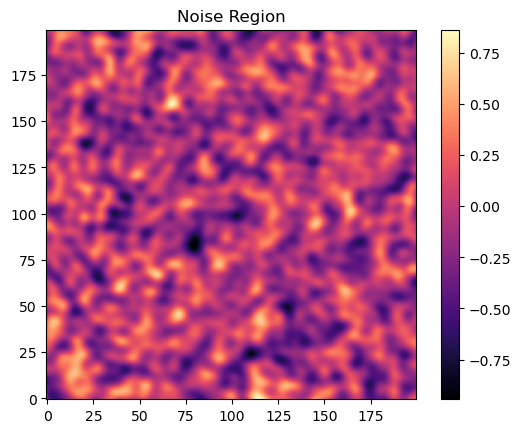

In [ ]:
# Example: choose a corner with no emission
noise_region = image[200:400, 200:400]
sigma = np.nanstd(noise_region.value)
print("Sigma (RMS noise):", sigma, "K")

plt.imshow(noise_region.value, origin='lower', cmap='magma')
plt.colorbar()
plt.title("Noise Region")
plt.show()